## Договорённости и протокол (актуальная версия)

### Цель задачи

* Обучить и сравнить модели, которые разделяют **NBRFI** (позитив) и **None** (негатив) на уровне **каналов**.
* Класс **NoneWNBRFI** **не используем в обучении**: он нужен как **hard negatives / стресс-тест**, чтобы проверить, не “стреляет” ли модель по каналам внутри `bright_NBRFI`, но вне частотных диапазонов RFI.

---

### Что такое классы в данных

* **NBRFI** — каналы, попадающие в частотные диапазоны RFI внутри сегментов, помеченных `bright_NBRFI`.
* **None** — каналы из сегментов, где исходная метка сегмента была отсутствующей (`NaN`), и мы трактуем это как “нет RFI”.

  * В CSV это отражено в `label`, где `NaN` мы **явно заменяем на строку `"None"`**.
* **NoneWNBRFI** — каналы внутри `bright_NBRFI` сегментов, но вне частотных диапазонов RFI: сложные отрицательные, похожие на позитивы по контексту.

---

### Признаки (что реально используем сейчас)

Используем фиксированный набор числовых статистик (16 колонок):

* `mean_o, std_o, skew_o, kurt_o`
* `mean_n, std_n, skew_n, kurt_n`
* `mean_o_ratio, std_o_ratio, skew_o_ratio, kurt_o_ratio`
* `mean_n_ratio, std_n_ratio, skew_n_ratio, kurt_n_ratio`

Таргет:

* `y = 1`, если `label == "NBRFI"`
* `y = 0`, если `label == "None"`

**Важно про NaN:** мы исправляем NaN **только в `label`**, чтобы не было скрытой деградации типов в признаках (числа не должны превращаться в `object`).

---

### Почему отсутствие кластеров на 2D-scatter не страшно

* Разделимость может проявляться:

  * только в **многомерной комбинации** признаков,
  * или быть **нелинейной** (не видна в проекциях).
* Поэтому 2D-графики — это диагностика, но не финальный критерий.

---

### Критически важный момент: anti-leakage split по группам

* “Объект” в датасете — **канал**, но каналы внутри одного сегмента сильно зависимы.
* Поэтому делаем **групповой split** (по `segment_index`/`global_index` на этапе подготовки сплитов), и используем готовые индексы:

  * `train_idx`, `val_idx`, `test_idx`
* Требование: все каналы одного сегмента попадают целиком **только в один сплит**.
* Это особенно важно из-за `*_ratio` (канал/сегмент), которые усиливают риск утечки при случайном строковом split.

---

### Стратегия работы с большим объёмом (первый этап)

* Полный массив большой, поэтому для быстрого цикла используем **сбалансированный поднабор**:

  * примерно `30k NBRFI + 30k None` (или аналогичный баланс).
* `NoneWNBRFI` в обучение не включаем.

---

### Правильный порядок формирования данных

1. Сначала строим **групповые** `train/val/test` индексы по сегментам.
2. Затем внутри train-сегментов сэмплируем нужное число каналов каждого класса (баланс).
3. Val/Test формируем аналогично (обычно меньше для скорости).

---

## Протокол обучения и сравнения моделей (то, что мы реализовали)

### Общий pipeline

* `X` = 16 числовых фич.
* Для большинства моделей применяем `StandardScaler` (деревьям он не нужен).
* Для каждой модели:

  1. обучаемся на `train`
  2. считаем вероятности/скор на `val`
  3. **подбираем порог на `val`** (в текущей реализации — по максимуму F1)
  4. оцениваем при этом пороге на `test`
  5. складываем всё в сравнительную таблицу

### Набор моделей (лестница сложности)

Мы сравниваем семейства, чтобы понять, какой тип границы нужен:

1. **SGD_LogReg** — линейная логистическая регрессия (SGD, `log_loss`)
   Проверяет: есть ли **линейный** сигнал в текущих фичах.

2. **SGD_LinearSVM** — линейный SVM (SGD, `hinge`)
   Проверяет: помогает ли “margin-критерий” при той же линейной границе.

3. **Poly2_LogReg** — полиномиальные признаки степени 2 + линейная логрег
   Проверяет: есть ли выигрыш от простых нелинейностей вида взаимодействий `x_i*x_j`.

4. **RBFapprox_LogReg** — аппроксимация RBF-ядра (Random Fourier Features) + линейная логрег
   Проверяет: нужен ли “RBF-тип” нелинейности (похоже на RBF-SVM, но масштабируемо).

5. **HistGB** — градиентный бустинг по деревьям
   Проверяет: насколько хорошо табличная нелинейная модель “вытаскивает” сигнал без ручных фич-маппингов.

6. **MLP** — небольшая нейросеть
   Проверяет: сможет ли универсальная нелинейная модель выучить нужные комбинации признаков.

---

### Метрики и порог

* На первом этапе (baseline/сравнение) используем метрики:

  * ROC-AUC, PR-AUC (качество ранжирования)
  * logloss (качество вероятностей/уверенности)
  * precision/recall/F1/accuracy **при выбранном пороге**
* Порог выбираем на `val` (сейчас: **max F1** как простая автоматизация).
* Дальше (когда подключим NoneWNBRFI) порог будем подбирать уже под ограничения на FP.

---

## Протокол оценки качества — два режима

1. **Основная валидация:** качество на задаче `NBRFI vs None` (train/val/test).
2. **Стресс-тест:** прогоняем модель на **NoneWNBRFI** и считаем:

   * FP-rate при фиксированном пороге,
   * распределение `p(NBRFI)` для NoneWNBRFI vs None vs NBRFI,
   * “насколько путает hard negatives с позитивом”.

---

## Что делаем дальше

* Запускаем сравнение моделей на текущем сбалансированном поднаборе и фиксируем таблицу результатов.
* По таблице выбираем 2–3 самых перспективных семейства (например: лучший линейный + лучший нелинейный).
* Добавляем **стресс-тест на NoneWNBRFI**:

  * графики распределений скоринга,
  * FP-rate при выбранном пороге,
  * подбор порога уже под ограничение FP на hard negatives.
* После первых результатов:

  * расширяем поднабор / усложняем фичи / тюним гиперпараметры.

---

Если хочешь, я ещё могу “свести” это в короткую “шапку ноутбука” (Markdown-ячейку) и отдельно сделать “чек-лист запуска” (что должно лежать рядом: csv, npz, список фич).


In [168]:
import glob
import time
import math
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.kernel_approximation import RBFSampler

from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance
from sklearn.base import clone

from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score, log_loss,
    precision_recall_fscore_support, classification_report, confusion_matrix 
)

from tqdm.notebook import tqdm, trange

In [2]:
meta_path  = "B0531+21_59000_48386_subset_channels_meta.csv"
split_path = "split_indices.npz"

meta = pd.read_csv(meta_path)

# ВАЖНО:
# Ты говорил, что NaN только в label и это "None". Исправляем ТОЛЬКО label,
# чтобы случайно не превратить числовые фичи в object.
meta["label"] = meta["label"].fillna("None")

splits = np.load(split_path)
train_idx = splits["train_idx"]
val_idx   = splits["val_idx"]
test_idx  = splits["test_idx"]

# Явно задаём список фичей (как ты прислал)
feature_cols = [
    'mean_o', 'std_o', 'skew_o', 'kurt_o',
    'mean_n', 'std_n', 'skew_n', 'kurt_n',
    'mean_o_ratio', 'std_o_ratio', 'skew_o_ratio', 'kurt_o_ratio',
    'mean_n_ratio', 'std_n_ratio', 'skew_n_ratio', 'kurt_n_ratio'
]

feature_sets = {
    "orig": [
        "mean_o", "std_o", "skew_o", "kurt_o",
        "mean_o_ratio", "std_o_ratio", "skew_o_ratio", "kurt_o_ratio",
    ],
    "norm": [
        "mean_n", "std_n", "skew_n", "kurt_n",
        "mean_n_ratio", "std_n_ratio", "skew_n_ratio", "kurt_n_ratio",
    ],
    "both": [
        "mean_o", "std_o", "skew_o", "kurt_o",
        "mean_n", "std_n", "skew_n", "kurt_n",
        "mean_o_ratio", "std_o_ratio", "skew_o_ratio", "kurt_o_ratio",
        "mean_n_ratio", "std_n_ratio", "skew_n_ratio", "kurt_n_ratio",
    ],
}

# На всякий случай проверим, что все колонки есть
missing_cols = [c for c in feature_cols if c not in meta.columns]
if missing_cols:
    raise ValueError(f"Нет колонок в meta: {missing_cols}")

# y: NBRFI=1, None=0
y_all = (meta["label"].values == "NBRFI").astype(int)

# X: только нужные признаки
X_all = meta[feature_cols].copy()

# Приведём к числам (на случай если где-то в csv числа лежат строками)
for c in feature_cols:
    X_all[c] = pd.to_numeric(X_all[c], errors="coerce")

print("meta shape:", meta.shape, "(rows=объекты/примеры)")
print("X_all shape:", X_all.shape)
print("labels counts:", np.unique(y_all, return_counts=True))
print("train/val/test:", len(train_idx), len(val_idx), len(test_idx))

# Проверка: нет ли NaN в признаках (ты говорил, что их нет)
nan_total = int(X_all.isna().sum().sum())
print("Total NaN in X_all:", nan_total)
if nan_total > 0:
    # не ломаем пайплайн, но явно предупреждаем
    print("WARNING: обнаружены NaN в признаках. Это не ожидалось по твоим данным.")

X_train = X_all.iloc[train_idx].reset_index(drop=True)
X_val   = X_all.iloc[val_idx].reset_index(drop=True)
X_test  = X_all.iloc[test_idx].reset_index(drop=True)

y_train = y_all[train_idx]
y_val   = y_all[val_idx]
y_test  = y_all[test_idx]


meta shape: (20000, 17) (rows=объекты/примеры)
X_all shape: (20000, 16)
labels counts: (array([0, 1]), array([10000, 10000]))
train/val/test: 16000 2000 2000
Total NaN in X_all: 0


### утилиты: выбор порога по val и расчёт метрик

In [3]:
def best_threshold_by_f1(y_true, p, grid=None):
    """
    Подбор порога по валидации.

    Что делаем:
    - Берём вероятности p (модельный скор 0..1).
    - Пробуем разные пороги.
    - Выбираем порог, который даёт максимум F1 на val.

    Что проверяем:
    - Можно ли "выжать" лучшее качество простым подбором порога,
      не меняя модель.
    """
    if grid is None:
        grid = np.linspace(0.01, 0.99, 99)

    best_t, best_f1 = 0.5, -1.0
    for t in grid:
        pred = (p >= t).astype(int)
        _, _, f1, _ = precision_recall_fscore_support(y_true, pred, average="binary", zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = float(t)
    return best_t, float(best_f1)


def eval_binary(y_true, p, threshold=0.5):
    """
    Считаем набор метрик для бинарной классификации.

    Что делаем:
    - p: вероятности класса 1 (NBRFI).
    - threshold: порог, выше которого считаем NBRFI.

    Что проверяем:
    - качество ранжирования (ROC-AUC, PR-AUC)
    - калибровку/уверенность (logloss)
    - качество решения при заданном пороге (precision/recall/f1/accuracy)
    """
    pred = (p >= threshold).astype(int)

    acc = accuracy_score(y_true, pred)
    roc = roc_auc_score(y_true, p) if len(np.unique(y_true)) == 2 else np.nan
    ap  = average_precision_score(y_true, p) if len(np.unique(y_true)) == 2 else np.nan

    # log_loss требует вероятности и наличие обоих классов
    ll = log_loss(y_true, np.c_[1-p, p], labels=[0, 1]) if len(np.unique(y_true)) == 2 else np.nan

    prec, rec, f1, _ = precision_recall_fscore_support(y_true, pred, average="binary", zero_division=0)

    return {
        "acc": float(acc),
        "precision": float(prec),
        "recall": float(rec),
        "f1": float(f1),
        "roc_auc": float(roc),
        "pr_auc": float(ap),
        "logloss": float(ll),
    }


### набор моделей со скейлером

In [7]:
# Здесь важная идея:
# Мы строим "лестницу" моделей от простого к более сложному.
# Каждая следующая модель проверяет, есть ли выгода от:
# - линейной границы,
# - другой линейной потери (SVM-hinge),
# - явных взаимодействий признаков (полином),
# - нелинейности типа RBF (через аппроксимацию ядра),
# - табличного сильного baseline (градиентный бустинг),
# - небольшой нейросети (MLP) как универсальной нелинейной модели.

models = {}

# 1) Линейная логистическая регрессия, обученная SGD (как у тебя)
# Что делаем:
# - строим линейную границу w·x + b
# - переводим в вероятность через сигмоиду
# Что проверяем:
# - есть ли линейный сигнал в статистических фичах (mean/std/skew/kurt и ratio)
models["SGD_LogReg"] = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("clf", SGDClassifier(
        loss="log_loss",      # логистический лосс = лог. регрессия
        alpha=1e-4,           # L2-регуляризация (чем больше, тем сильнее "сжимает" веса)
        max_iter=2000,
        tol=1e-3,
        random_state=42
    ))
])

# 2) Линейный SVM через SGD (hinge loss)
# Что делаем:
# - тоже линейная граница
# - но оптимизируем hinge loss (SVM-идея: максимизируем margin)
# Что проверяем:
# - поможет ли другой критерий (margin) вместо логлосса при тех же фичах
models["SGD_LinearSVM"] = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("clf", SGDClassifier(
        loss="hinge",         # hinge = линейный SVM
        alpha=1e-4,
        max_iter=2000,
        tol=1e-3,
        random_state=42
    ))
])

# 3) Полиномиальные признаки (2 степень) + линейная логрег
# Что делаем:
# - расширяем пространство признаков: добавляем x_i*x_j и x_i^2
# - после этого линейная модель в новом пространстве == нелинейная граница в исходном
# Что проверяем:
# - есть ли простая нелинейность вида "взаимодействий" между статистиками
models["Poly2_LogReg"] = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("clf", SGDClassifier(
        loss="log_loss",
        alpha=1e-4,
        max_iter=2000,
        tol=1e-3,
        random_state=42
    ))
])

# 4) Аппроксимация RBF-ядра (Random Fourier Features) + линейная логрег
# Что делаем:
# - RBFSampler превращает x -> z(x) так, что линейная модель по z(x)
#   приближает RBF-SVM (нелинейную границу)
# Что проверяем:
# - нужен ли "RBF-тип" нелинейности для отделения NBRFI от None
models["RBFapprox_LogReg"] = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("rbf", RBFSampler(gamma=1.0, n_components=800, random_state=42)),
    ("clf", SGDClassifier(
        loss="log_loss",
        alpha=1e-4,
        max_iter=2000,
        tol=1e-3,
        random_state=42
    ))
])

# 5) Градиентный бустинг по деревьям (Histogram-based)
# Что делаем:
# - сильная табличная модель: строит ансамбль деревьев, умеет сложные границы,
#   автоматически ловит взаимодействия и нелинейности
# Что проверяем:
# - "если в данных есть сигнал", то бустинг часто вытягивает его лучше линейных моделей
models["HistGB"] = Pipeline(steps=[
    # скейлер не нужен деревьям, но не мешает; здесь уберём ради ясности:
    ("clf", HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_depth=6,
        max_iter=300,
        random_state=42
    ))
])

# 6) MLP (небольшая нейросеть)
# Что делаем:
# - универсальная нелинейная модель, сама учит комбинации признаков
# Что проверяем:
# - есть ли нелинейная структура, которую проще поймать MLP, чем явным poly/RBF
models["MLP"] = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=200,
        random_state=42
    ))
])

print("Models:", list(models.keys()))

Models: ['SGD_LogReg', 'SGD_LinearSVM', 'Poly2_LogReg', 'RBFapprox_LogReg', 'HistGB', 'MLP']


## Набор моделей без скейлера

In [4]:
models_no_scaler = {}

# 1) SGD LogReg
models_no_scaler["SGD_LogReg"] = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=0.0)),
    ("clf", SGDClassifier(
        loss="log_loss",
        alpha=1e-4,
        max_iter=2000,
        tol=1e-3,
        random_state=42
    ))
])

# 2) SGD Linear SVM (hinge)
models_no_scaler["SGD_LinearSVM"] = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=0.0)),
    ("clf", SGDClassifier(
        loss="hinge",
        alpha=1e-4,
        max_iter=2000,
        tol=1e-3,
        random_state=42
    ))
])

# 3) Poly2 + LogReg
models_no_scaler["Poly2_LogReg"] = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=0.0)),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("clf", SGDClassifier(
        loss="log_loss",
        alpha=1e-4,
        max_iter=2000,
        tol=1e-3,
        random_state=42
    ))
])

# 4) RBF approx + LogReg
models_no_scaler["RBFapprox_LogReg"] = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=0.0)),
    ("rbf", RBFSampler(gamma=1.0, n_components=800, random_state=42)),
    ("clf", SGDClassifier(
        loss="log_loss",
        alpha=1e-4,
        max_iter=2000,
        tol=1e-3,
        random_state=42
    ))
])

# 5) HistGB (деревья, импер можно оставить для единообразия)
models_no_scaler["HistGB"] = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=0.0)),
    ("clf", HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_depth=6,
        max_iter=300,
        random_state=42
    ))
])

# 6) MLP
models_no_scaler["MLP"] = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=0.0)),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=200,
        random_state=42
    ))
])

### обучение, подбор порога по val, оценка на test, сравнительная таблица

In [5]:
from scipy.special import expit

results = []
fitted_models = {}  # ключ: (fs_name, model_name)

total = len(feature_sets) * len(models_no_scaler)

with tqdm(total=total, desc="Training (feat_set × model)") as pbar:
    for fs_name, cols in feature_sets.items():
        X_train_fs = X_train[cols]
        X_val_fs   = X_val[cols]
        X_test_fs  = X_test[cols]

        for name, pipe in models_no_scaler.items():
            m = clone(pipe)

            t0 = time.time()
            m.fit(X_train_fs, y_train)
            fit_time = time.time() - t0

            # скор/вероятности
            if hasattr(m, "predict_proba"):
                p_val  = m.predict_proba(X_val_fs)[:, 1]
                p_test = m.predict_proba(X_test_fs)[:, 1]
            else:
                s_val  = m.decision_function(X_val_fs)
                s_test = m.decision_function(X_test_fs)
            
                p_val  = expit(s_val)
                p_test = expit(s_test)

            best_t, _ = best_threshold_by_f1(y_val, p_val)
            val_metrics  = eval_binary(y_val,  p_val,  threshold=best_t)
            test_metrics = eval_binary(y_test, p_test, threshold=best_t)

            results.append({
                "feat_set": fs_name,
                "model": name,
                "fit_time_s": round(fit_time, 3),
                "best_thr_val": round(best_t, 3),

                "val_f1": round(val_metrics["f1"], 4),
                "val_pr_auc": round(val_metrics["pr_auc"], 4),
                "val_roc_auc": round(val_metrics["roc_auc"], 4),

                "test_f1": round(test_metrics["f1"], 4),
                "test_pr_auc": round(test_metrics["pr_auc"], 4),
                "test_roc_auc": round(test_metrics["roc_auc"], 4),
                "test_acc": round(test_metrics["acc"], 4),
            })

            fitted_models[(fs_name, name)] = m

            # обновляем прогресс + показываем, что сейчас сделали
            pbar.set_postfix({"feat_set": fs_name, "model": name, "fit_s": f"{fit_time:.2f}"})
            pbar.update(1)

df = pd.DataFrame(results)
df_sorted = df.sort_values(["feat_set", "val_f1", "val_pr_auc"], ascending=[True, False, False]).reset_index(drop=True)
df_sorted

Training (feat_set × model):   0%|          | 0/18 [00:00<?, ?it/s]

,feat_set,model,fit_time_s,best_thr_val,val_f1,val_pr_auc,val_roc_auc,test_f1,test_pr_auc,test_roc_auc,test_acc
0,both,HistGB,0.887,0.22,0.9920,0.9994,0.9994,0.9875,0.9989,0.9988,0.9875
1,both,MLP,5.428,0.62,0.9665,0.9919,0.9887,0.9612,0.9907,0.9865,0.9625
2,both,SGD_LogReg,0.040,0.99,0.9267,0.9285,0.9430,0.9309,0.9259,0.9434,0.9325
3,both,SGD_LinearSVM,0.030,0.08,0.9260,0.9297,0.9419,0.9289,0.9232,0.9397,0.9310
4,both,Poly2_LogReg,0.156,0.01,0.9175,0.8916,0.9190,0.9155,0.8858,0.9165,0.9165
5,both,RBFapprox_LogReg,1.061,0.01,0.6667,0.4934,0.4870,0.6667,0.5090,0.5068,0.5000
6,norm,MLP,12.865,0.38,0.6669,0.7059,0.6443,0.6669,0.6924,0.6181,0.5035
7,norm,HistGB,0.600,0.01,0.6667,0.7108,0.6380,0.6667,0.7238,0.6520,0.5000
8,norm,RBFapprox_LogReg,1.029,0.01,0.6667,0.5188,0.5226,0.6667,0.5127,0.5160,0.5000
9,norm,Poly2_LogReg,0.686,0.01,0.2828,0.5714,0.5775,0.2956,0.5789,0.5830,0.5830


### Поиск наиболее важных признаков

In [6]:
def permutation_importance_by_featset(fitted_models, X_val, y_val, feature_sets,
                                      scoring="average_precision",
                                      n_repeats=10, random_state=42):
    """
    fitted_models: dict с ключами (fs_name, model_name) -> fitted_pipeline
    X_val: полный DataFrame со всеми 16 фичами
    feature_sets: {"orig":[...], "norm":[...], "both":[...]}
    """
    rows = []

    for (fs_name, model_name), model in tqdm(fitted_models.items(),
                                             total=len(fitted_models),
                                             desc="Permutation importance"):
        cols = feature_sets[fs_name]
        Xv = X_val[cols]

        perm = permutation_importance(
            model, Xv, y_val,
            n_repeats=n_repeats,
            random_state=random_state,
            scoring=scoring
        )

        # складываем в "длинную" таблицу
        for feat, m, s in zip(cols, perm.importances_mean, perm.importances_std):
            rows.append({
                "feat_set": fs_name,
                "model": model_name,
                "feature": feat,
                "imp_mean": float(m),
                "imp_std": float(s),
            })

    imp_long = pd.DataFrame(rows)

    # если хочешь матрицу как раньше (модель x фича) — делаем pivot отдельно по каждому fs
    imp_pivots = {}
    for fs_name in feature_sets.keys():
        sub = imp_long[imp_long["feat_set"] == fs_name]
        imp_pivots[fs_name] = sub.pivot(index="model", columns="feature", values="imp_mean")

    return imp_long, imp_pivots


imp_long, imp_pivots = permutation_importance_by_featset(
    fitted_models=fitted_models,
    X_val=X_val, y_val=y_val,
    feature_sets=feature_sets,
    scoring="average_precision",
    n_repeats=10,
    random_state=42
)

# Например, посмотреть матрицу важностей для "both":
imp_pivots["both"]

Permutation importance:   0%|          | 0/18 [00:00<?, ?it/s]

feature,kurt_n,kurt_n_ratio,kurt_o,kurt_o_ratio,mean_n,mean_n_ratio,mean_o,mean_o_ratio,skew_n,skew_n_ratio,skew_o,skew_o_ratio,std_n,std_n_ratio,std_o,std_o_ratio
model,,,,,,,,,,,,,,,,
HistGB,0.000000,0.000065,0.000413,0.001543,0.000048,-2.650172e-05,0.197079,2.686473e-03,0.000000,0.000046,-0.000031,0.000162,0.000007,-0.000005,0.006765,0.078460
MLP,0.004026,0.044885,0.005941,0.007452,0.007271,3.433027e-05,0.373919,-1.027795e-05,0.004086,0.031656,0.003862,0.069686,0.003752,-0.000092,0.034871,0.000937
Poly2_LogReg,-0.000005,0.047649,-0.000005,0.036731,0.005912,2.398315e-07,0.362575,-3.085626e-07,0.000004,0.000160,0.000004,0.000501,0.007334,-0.000002,0.030108,0.000036
RBFapprox_LogReg,0.003127,-0.000562,0.000573,-0.002512,-0.015898,3.468057e-03,0.002970,-5.378191e-03,-0.004905,0.003420,-0.006023,-0.007389,-0.004445,0.002514,-0.002424,0.001411
SGD_LinearSVM,0.020429,0.001617,0.020429,0.002726,0.010216,-3.274052e-06,0.372620,-2.486059e-06,0.000051,0.009449,0.000051,0.002929,-0.001268,-0.000006,0.079490,0.000030
SGD_LogReg,0.019931,0.001879,0.019931,0.002921,0.010475,-1.156021e-06,0.373902,-1.571104e-06,0.000063,0.008487,0.000063,0.003094,-0.001058,-0.000003,0.079127,0.000058


In [7]:
def topk_features(imp_pivot, k=3):
    out = {}
    for model_name in imp_pivot.index:
        s = imp_pivot.loc[model_name].sort_values(ascending=False)
        out[model_name] = s.index[:k].tolist()
    return out

top3_both = topk_features(imp_pivots["both"], k=3)
top3_orig = topk_features(imp_pivots["orig"], k=3)
top3_norm = topk_features(imp_pivots["norm"], k=3)

In [8]:
top3_both

{'HistGB': ['mean_o', 'std_o_ratio', 'std_o'],
 'MLP': ['mean_o', 'skew_o_ratio', 'kurt_n_ratio'],
 'Poly2_LogReg': ['mean_o', 'kurt_n_ratio', 'kurt_o_ratio'],
 'RBFapprox_LogReg': ['mean_n_ratio', 'skew_n_ratio', 'kurt_n'],
 'SGD_LinearSVM': ['mean_o', 'std_o', 'kurt_o'],
 'SGD_LogReg': ['mean_o', 'std_o', 'kurt_o']}

In [9]:
top3_orig

{'HistGB': ['mean_o', 'std_o_ratio', 'std_o'],
 'MLP': ['mean_o', 'std_o', 'skew_o'],
 'Poly2_LogReg': ['mean_o', 'std_o', 'kurt_o_ratio'],
 'RBFapprox_LogReg': ['mean_o', 'kurt_o_ratio', 'std_o'],
 'SGD_LinearSVM': ['mean_o', 'std_o', 'kurt_o'],
 'SGD_LogReg': ['mean_o', 'std_o', 'kurt_o']}

In [10]:
top3_norm

{'HistGB': ['std_n', 'kurt_n_ratio', 'mean_n'],
 'MLP': ['kurt_n_ratio', 'kurt_n', 'skew_n_ratio'],
 'Poly2_LogReg': ['kurt_n_ratio', 'std_n', 'skew_n_ratio'],
 'RBFapprox_LogReg': ['std_n', 'skew_n_ratio', 'kurt_n_ratio'],
 'SGD_LinearSVM': ['skew_n_ratio', 'std_n', 'skew_n'],
 'SGD_LogReg': ['skew_n_ratio', 'std_n', 'skew_n']}

In [15]:
def _get_scores_as_prob(model, X):
    """Вернуть p(class=1) для любого sklearn-моделя/пайплайна."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    elif hasattr(model, "decision_function"):
        return expit(model.decision_function(X))  # стабильная сигмоида
    else:
        raise AttributeError(f"Model {type(model)} has neither predict_proba nor decision_function")

def fit_eval_subset_for_all_by_featset(models, feature_sets,
                                       X_train, y_train, X_val, y_val, X_test, y_test,
                                       imp_pivots, k=3):
    rows = []

    for fs_name, cols_full in feature_sets.items():
        Xtr = X_train[cols_full]
        Xva = X_val[cols_full]
        Xte = X_test[cols_full]

        imp_df = imp_pivots[fs_name]  # index=model_name, columns=features

        for model_name, base_model in tqdm(models.items(),
                                           total=len(models),
                                           desc=f"Refit top-{k} | {fs_name}"):
            if model_name not in imp_df.index:
                continue

            cols_topk = imp_df.loc[model_name].sort_values(ascending=False).index[:k].tolist()

            # --- full features ---
            m_full = clone(base_model)
            m_full.fit(Xtr, y_train)

            p_val_full  = _get_scores_as_prob(m_full, Xva)
            p_test_full = _get_scores_as_prob(m_full, Xte)

            t_full, _ = best_threshold_by_f1(y_val, p_val_full)
            test_full = eval_binary(y_test, p_test_full, threshold=t_full)

            # --- top-k features ---
            m_sub = clone(base_model)
            m_sub.fit(X_train[cols_topk], y_train)

            p_val_sub  = _get_scores_as_prob(m_sub, X_val[cols_topk])
            p_test_sub = _get_scores_as_prob(m_sub, X_test[cols_topk])

            t_sub, _ = best_threshold_by_f1(y_val, p_val_sub)
            test_sub = eval_binary(y_test, p_test_sub, threshold=t_sub)

            rows.append({
                "feat_set": fs_name,
                "model": model_name,
                "top_features": cols_topk,

                "test_f1_full": round(test_full["f1"], 4),
                "test_f1_topk": round(test_sub["f1"], 4),
                "test_pr_auc_full": round(test_full["pr_auc"], 4),
                "test_pr_auc_topk": round(test_sub["pr_auc"], 4),
                "test_acc_full": round(test_full["acc"], 4),
                "test_acc_topk": round(test_sub["acc"], 4),
            })

    return (pd.DataFrame(rows)
              .sort_values(["feat_set", "test_f1_topk"], ascending=[True, False])
              .reset_index(drop=True))


subset_compare = fit_eval_subset_for_all_by_featset(
    models=models_no_scaler,          # или models, если ты оставил scaler
    feature_sets=feature_sets,
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test,
    imp_pivots=imp_pivots,            # из permutation_importance_by_featset
    k=3
)

subset_compare

Refit top-3 | orig:   0%|          | 0/6 [00:00<?, ?it/s]

Refit top-3 | norm:   0%|          | 0/6 [00:00<?, ?it/s]

Refit top-3 | both:   0%|          | 0/6 [00:00<?, ?it/s]

,feat_set,model,top_features,test_f1_full,test_f1_topk,test_pr_auc_full,test_pr_auc_topk,test_acc_full,test_acc_topk
0,both,HistGB,"[mean_o, std_o_ratio, std_o]",0.9875,0.9884,0.9989,0.9984,0.9875,0.9885
1,both,SGD_LogReg,"[mean_o, std_o, kurt_o]",0.9309,0.9609,0.9259,0.9836,0.9325,0.9620
2,both,SGD_LinearSVM,"[mean_o, std_o, kurt_o]",0.9289,0.9537,0.9232,0.9840,0.9310,0.9545
3,both,MLP,"[mean_o, skew_o_ratio, kurt_n_ratio]",0.9612,0.9534,0.9907,0.9791,0.9625,0.9545
4,both,Poly2_LogReg,"[mean_o, kurt_n_ratio, kurt_o_ratio]",0.9155,0.7696,0.8858,0.6511,0.9165,0.7270
5,both,RBFapprox_LogReg,"[mean_n_ratio, skew_n_ratio, kurt_n]",0.6667,0.6667,0.5090,0.6363,0.5000,0.5000
6,norm,SGD_LogReg,"[skew_n_ratio, std_n, skew_n]",0.1980,0.6678,0.5564,0.6345,0.5260,0.5045
7,norm,SGD_LinearSVM,"[skew_n_ratio, std_n, skew_n]",0.2178,0.6669,0.5541,0.6361,0.5295,0.5005
8,norm,HistGB,"[std_n, kurt_n_ratio, mean_n]",0.6667,0.6667,0.7238,0.6812,0.5000,0.5015
9,norm,MLP,"[kurt_n_ratio, kurt_n, skew_n_ratio]",0.6669,0.6667,0.6924,0.6996,0.5035,0.5000


In [23]:
subset_compare.sort_values(["test_pr_auc_topk"], ascending=[False])

,feat_set,model,top_features,test_f1_full,test_f1_topk,test_pr_auc_full,test_pr_auc_topk,test_acc_full,test_acc_topk
0,both,HistGB,"[mean_o, std_o_ratio, std_o]",0.9875,0.9884,0.9989,0.9984,0.9875,0.9885
12,orig,HistGB,"[mean_o, std_o_ratio, std_o]",0.9870,0.9884,0.9988,0.9984,0.9870,0.9885
14,orig,MLP,"[mean_o, std_o, skew_o]",0.9636,0.9552,0.9909,0.9849,0.9640,0.9560
2,both,SGD_LinearSVM,"[mean_o, std_o, kurt_o]",0.9289,0.9537,0.9232,0.9840,0.9310,0.9545
15,orig,SGD_LinearSVM,"[mean_o, std_o, kurt_o]",0.9260,0.9537,0.9555,0.9840,0.9295,0.9545
1,both,SGD_LogReg,"[mean_o, std_o, kurt_o]",0.9309,0.9609,0.9259,0.9836,0.9325,0.9620
13,orig,SGD_LogReg,"[mean_o, std_o, kurt_o]",0.8452,0.9609,0.7652,0.9836,0.8275,0.9620
3,both,MLP,"[mean_o, skew_o_ratio, kurt_n_ratio]",0.9612,0.9534,0.9907,0.9791,0.9625,0.9545
17,orig,RBFapprox_LogReg,"[mean_o, kurt_o_ratio, std_o]",0.7970,0.8866,0.8076,0.9327,0.7695,0.8805
16,orig,Poly2_LogReg,"[mean_o, std_o, kurt_o_ratio]",0.9165,0.9145,0.8765,0.8789,0.9155,0.9145


In [24]:
selected = [('HistGB', 'both'), ('HistGB', 'orig'), ('MLP', 'orig')]

In [25]:
def _prob(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        return expit(model.decision_function(X))
    raise AttributeError("Model has neither predict_proba nor decision_function")

def save_selected_topk_models(
    selected_pairs,          # [('HistGB','both'), ...]
    models_dict,             # models_no_scaler или models
    imp_pivots,              # dict: fs -> pivot(model x feature)
    feature_sets,            # dict: fs -> list of feature cols
    X_train, y_train, X_val, y_val,
    K=3,
    out_dir="saved_models_selected_topk"
):
    out_dir = Path(out_dir)
    out_dir.mkdir(exist_ok=True)

    saved = 0
    for model_name, fs_name in selected_pairs:
        if fs_name not in feature_sets:
            raise ValueError(f"Unknown feat_set='{fs_name}'. Available: {list(feature_sets.keys())}")
        if model_name not in models_dict:
            raise ValueError(f"Unknown model='{model_name}'. Available: {list(models_dict.keys())}")
        if fs_name not in imp_pivots:
            raise ValueError(f"No imp_pivot for feat_set='{fs_name}'. Available: {list(imp_pivots.keys())}")
        if model_name not in imp_pivots[fs_name].index:
            raise ValueError(f"Model '{model_name}' not found in imp_pivots['{fs_name}'] index")

        # --- top-K фичи для этой пары (model, feat_set) ---
        cols_topk = (imp_pivots[fs_name]
                     .loc[model_name]
                     .sort_values(ascending=False)
                     .index[:K]
                     .tolist())

        # --- обучаем модель строго на top-K ---
        pipe = clone(models_dict[model_name])
        pipe.fit(X_train[cols_topk], y_train)

        # --- подбираем порог на val ---
        p_val = _prob(pipe, X_val[cols_topk])
        best_t, best_val_f1 = best_threshold_by_f1(y_val, p_val)

        bundle = {
            "model_name": f"{model_name}_{fs_name}_top{K}",
            "base_model": model_name,
            "feat_set": fs_name,
            "topK": int(K),
            "threshold": float(best_t),
            "feature_cols": cols_topk,      # <-- ВАЖНО: сохраняем именно top_features
            "pipeline": pipe,
            "val_f1_at_thr": float(best_val_f1),
        }

        out_path = out_dir / f"rfi_model_{model_name}_{fs_name}_top{K}.joblib"
        joblib.dump(bundle, out_path, compress=("xz", 3))
        saved += 1

        print(f"Saved: {out_path} | cols={cols_topk} | thr={best_t:.3f}")

    print("Total saved:", saved, "->", str(out_dir))

In [26]:
save_selected_topk_models(
    selected_pairs=selected,
    models_dict=models_no_scaler,   # или models
    imp_pivots=imp_pivots,
    feature_sets=feature_sets,
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    K=3,
    out_dir="saved_models_selected_topk"
)

Saved: saved_models_selected_topk/rfi_model_HistGB_both_top3.joblib | cols=['mean_o', 'std_o_ratio', 'std_o'] | thr=0.520
Saved: saved_models_selected_topk/rfi_model_HistGB_orig_top3.joblib | cols=['mean_o', 'std_o_ratio', 'std_o'] | thr=0.520
Saved: saved_models_selected_topk/rfi_model_MLP_orig_top3.joblib | cols=['mean_o', 'std_o', 'skew_o'] | thr=0.230
Total saved: 3 -> saved_models_selected_topk


### Тестирвоание моделей 

In [87]:
models_list = glob.glob('./saved_models_selected_topk/*.joblib')
models_list

['./saved_models_selected_topk/rfi_model_HistGB_both_top3.joblib',
 './saved_models_selected_topk/rfi_model_MLP_orig_top3.joblib',
 './saved_models_selected_topk/rfi_model_HistGB_orig_top3.joblib']

In [88]:
import glob, os

for f in sorted(glob.glob("saved_models_selected_topk/*.joblib"))[:5]:
    size_mb = os.path.getsize(f)/1024/1024
    b = joblib.load(f)
    print(f, f"| {size_mb:.2f} MB | cols={b['feature_cols']} | thr={b['threshold']:.3f}")

saved_models_selected_topk/rfi_model_HistGB_both_top3.joblib | 0.22 MB | cols=['mean_o', 'std_o_ratio', 'std_o'] | thr=0.520
saved_models_selected_topk/rfi_model_HistGB_orig_top3.joblib | 0.22 MB | cols=['mean_o', 'std_o_ratio', 'std_o'] | thr=0.520
saved_models_selected_topk/rfi_model_MLP_orig_top3.joblib | 0.06 MB | cols=['mean_o', 'std_o', 'skew_o'] | thr=0.230


In [89]:
bundle = joblib.load(models_list[1]) 

model_name   = bundle["model_name"]
threshold    = float(bundle["threshold"])
feature_cols = bundle["feature_cols"]
pipe         = bundle["pipeline"]

print("Loaded model:", model_name)
print("Threshold:", threshold)
print("Features:", feature_cols)

Loaded model: MLP_orig_top3
Threshold: 0.23
Features: ['mean_o', 'std_o', 'skew_o']


In [90]:
def compute_stats(x: np.ndarray, axis=None):
    """
    Возвращает mean, std, skew, kurt (excess) по заданной оси.
    """
    x = np.asarray(x)
    mean = x.mean(axis=axis, keepdims=True)
    std  = x.std(axis=axis, keepdims=True)

    centered = x - mean
    m2 = (centered ** 2).mean(axis=axis, keepdims=True)
    m3 = (centered ** 3).mean(axis=axis, keepdims=True)
    m4 = (centered ** 4).mean(axis=axis, keepdims=True)

    std_safe = np.where(std == 0, 1.0, std)
    skew = m3 / (std_safe ** 3)
    kurt = m4 / (std_safe ** 4) - 3.0

    return mean.squeeze(), std.squeeze(), skew.squeeze(), kurt.squeeze()


def normalize_per_channel(seg: np.ndarray) -> np.ndarray:
    """
    Нормализация каждого частотного канала (строки) в [0, 256].
    seg: (n_channels, n_time)
    """
    seg = np.asarray(seg)
    chan_min = seg.min(axis=1, keepdims=True)
    chan_max = seg.max(axis=1, keepdims=True)
    denom = chan_max - chan_min
    denom_safe = np.where(denom == 0, 1.0, denom)
    return (seg - chan_min) / denom_safe * 256.0


def compute_ratio(per_channel_vals: np.ndarray, seg_val: float) -> np.ndarray:
    """
    Отношение параметра канала к параметру всего сегмента.
    Если seg_val == 0, возвращаем NaN.
    """
    per_channel_vals = np.asarray(per_channel_vals, dtype=float)
    if seg_val == 0:
        return np.full_like(per_channel_vals, np.nan, dtype=float)
    return per_channel_vals / seg_val


def extract_features_from_segment(seg: np.ndarray) -> pd.DataFrame:
    """
    seg: (n_channels, 256)  - как у тебя data после get_data_from_filterbank(...).T
    Возвращает DataFrame (n_channels, 16) с колонками:
      mean_o, std_o, skew_o, kurt_o,
      mean_n, std_n, skew_n, kurt_n,
      mean_o_ratio, ... kurt_n_ratio
    """
    seg = np.asarray(seg)
    if seg.ndim != 2:
        raise ValueError(f"Expected seg with shape (n_channels, n_time), got {seg.shape}")

    # 1) per-channel stats on original (axis=1 => по времени)
    mean_o, std_o, skew_o, kurt_o = compute_stats(seg, axis=1)

    # 2) normalized per-channel segment + per-channel stats
    seg_n = normalize_per_channel(seg)
    mean_n, std_n, skew_n, kurt_n = compute_stats(seg_n, axis=1)

    # 3) segment-level stats (по всем значениям сегмента)
    seg_mean_o, seg_std_o, seg_skew_o, seg_kurt_o = compute_stats(seg, axis=None)
    seg_mean_n, seg_std_n, seg_skew_n, seg_kurt_n = compute_stats(seg_n, axis=None)

    # 4) ratios
    mean_o_ratio = compute_ratio(mean_o, seg_mean_o)
    std_o_ratio  = compute_ratio(std_o,  seg_std_o)
    skew_o_ratio = compute_ratio(skew_o, seg_skew_o)
    kurt_o_ratio = compute_ratio(kurt_o, seg_kurt_o)

    mean_n_ratio = compute_ratio(mean_n, seg_mean_n)
    std_n_ratio  = compute_ratio(std_n,  seg_std_n)
    skew_n_ratio = compute_ratio(skew_n, seg_skew_n)
    kurt_n_ratio = compute_ratio(kurt_n, seg_kurt_n)

    df = pd.DataFrame({
        "mean_o": mean_o, "std_o": std_o, "skew_o": skew_o, "kurt_o": kurt_o,
        "mean_n": mean_n, "std_n": std_n, "skew_n": skew_n, "kurt_n": kurt_n,
        "mean_o_ratio": mean_o_ratio, "std_o_ratio": std_o_ratio,
        "skew_o_ratio": skew_o_ratio, "kurt_o_ratio": kurt_o_ratio,
        "mean_n_ratio": mean_n_ratio, "std_n_ratio": std_n_ratio,
        "skew_n_ratio": skew_n_ratio, "kurt_n_ratio": kurt_n_ratio,
    })

    return df

In [91]:
import your
from astropy import units as u

def get_data_from_filterbank(filterbank_file, index, rand=0):
    steps = range(0, filterbank_file.your_header.nspectra, 256)
    return filterbank_file.get_data(nstart=steps[index] + rand, nsamp=256).T  # (n_chan, 256)

filterbank_file_path = "/hercules/results/akazantsev/filterbank_files/B0531+21/B0531+21_59000_48386.fil"  # <- поменяй
# filterbank_file_path = '/hercules/results/akazantsev/filterbank_files/B0531+21/B0531+21_60482_48780.fil'
filterbank_file = your.Your(filterbank_file_path)

f_first = filterbank_file.your_header.fch1 * u.megahertz
f_last  = (filterbank_file.your_header.fch1 + filterbank_file.your_header.bw) * u.megahertz
tsamp   = filterbank_file.your_header.tsamp * u.second

print("f_first:", f_first, "f_last:", f_last, "tsamp:", tsamp)


f_first: 1530.0 MHz f_last: 1210.0 MHz tsamp: 0.0001024 s


In [92]:
def predict_mask_for_segment(seg: np.ndarray, pipe, threshold: float, feature_cols: list):
    """
    Возвращает:
      row_mask_bool: (n_channels,) bool
      probs: (n_channels,) float
      feats_df: (n_channels, 16) DataFrame
    """
    feats = extract_features_from_segment(seg)
    # гарантируем порядок колонок как при обучении
    feats = feats[feature_cols]

    # вероятности
    if hasattr(pipe, "predict_proba"):
        probs = pipe.predict_proba(feats)[:, 1]
    else:
        # на случай hinge-модели без predict_proba
        scores = pipe.decision_function(feats)
        probs = expit(scores)

    mask = probs >= threshold
    return mask, probs, feats


In [211]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_spec_with_mask_sklearn(filterbank_file, index, pipe, threshold, feature_cols, title_name="", addition_to_title="", plot=False,
                                save=False, out_dir='', random_shift=False, random_seed=42):
    data = get_data_from_filterbank(filterbank_file, index)  # (n_chan, 256)
    dy = dx = 0

    rng = np.random.default_rng(random_seed)
    if random_shift:
        dy = int(rng.integers(50, 150))
        dx = int(rng.integers(50, 150))
        data = np.roll(data, shift=(dy, dx), axis=(0, 1))

    row_mask, probs, feats = predict_mask_for_segment(data, pipe, threshold, feature_cols)
    H, W = data.shape
    overlay = np.repeat(row_mask[:, None], W, axis=1).astype(float)

    cmap_black = ListedColormap([(0, 0, 0, 0.0), (0, 0, 0, 1.0)])
    vmin, vmax = float(np.min(data)), float(np.max(data))

    extent = [0, W, float(f_last.value), float(f_first.value)]

    if plot:
        plt.clf()
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
        fig.suptitle(
            f"Index {index} | Model: {title_name} | thr={threshold:.3f}\nShift: dx={dx}, dy={dy}{addition_to_title}",
            fontsize=13
        )
    
        ax1.imshow(data, cmap="gray", vmin=vmin, vmax=vmax, extent=extent, aspect="auto", origin="upper")
        ax1.set_title("Original")
        ax1.set_xlabel(f"Time samples (dt={tsamp.to(u.microsecond):.1f})")
        ax1.set_ylabel("Frequency")
    
        ax2.imshow(data, cmap="gray", vmin=vmin, vmax=vmax, extent=extent, aspect="auto", origin="upper")
        ax2.imshow(overlay, cmap=cmap_black, vmin=0, vmax=1, extent=extent, aspect="auto", origin="upper")
        ax2.set_title("With mask")
        ax2.set_xlabel(f"Time samples (dt={tsamp.to(u.microsecond):.1f})")
    
        plt.tight_layout()
    
        if save:
            Path(out_dir).mkdir(parents=True, exist_ok=True)
            out = f"{out_dir}{os.sep}spec_with_mask_{model_name}_idx_{index}_dx_{dx}_dy_{dy}.png"
            plt.savefig(out, dpi=250)
            # print("Saved:", out)
        else:
            plt.show()
    
    return row_mask, probs, feats


def plot_one_channel(filterbank_file, segment_index: int, channel_index: int, title: str = ""):
    """
    Рисует один частотный канал (временной ряд) из сегмента.

    filterbank_file: your.Your(...)
    segment_index: индекс сегмента (как у тебя в get_data_from_filterbank)
    channel_index: номер частотного канала (0..n_channels-1)
    title: заголовок графика
    """
    # достаём сегмент (n_chan, 256) как в твоём коде
    steps = range(0, filterbank_file.your_header.nspectra, 256)
    seg = filterbank_file.get_data(nstart=steps[segment_index], nsamp=256).T  # (n_chan, 256)
    tsamp   = filterbank_file.your_header.tsamp * u.second

    if channel_index < 0 or channel_index >= seg.shape[0]:
        raise ValueError(f"channel_index out of range: {channel_index}, valid: 0..{seg.shape[0]-1}")

    y = np.asarray(seg[channel_index], dtype=float)

    plt.figure(figsize=(10, 3))
    plt.plot(y, color='black')
    plt.title(title or f"segment={segment_index}, channel={channel_index}")
    plt.xlabel(f"Time samples (dt={tsamp.to(u.microsecond):.1f})")
    plt.ylabel("Amplitude")
    plt.grid(True, ls='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

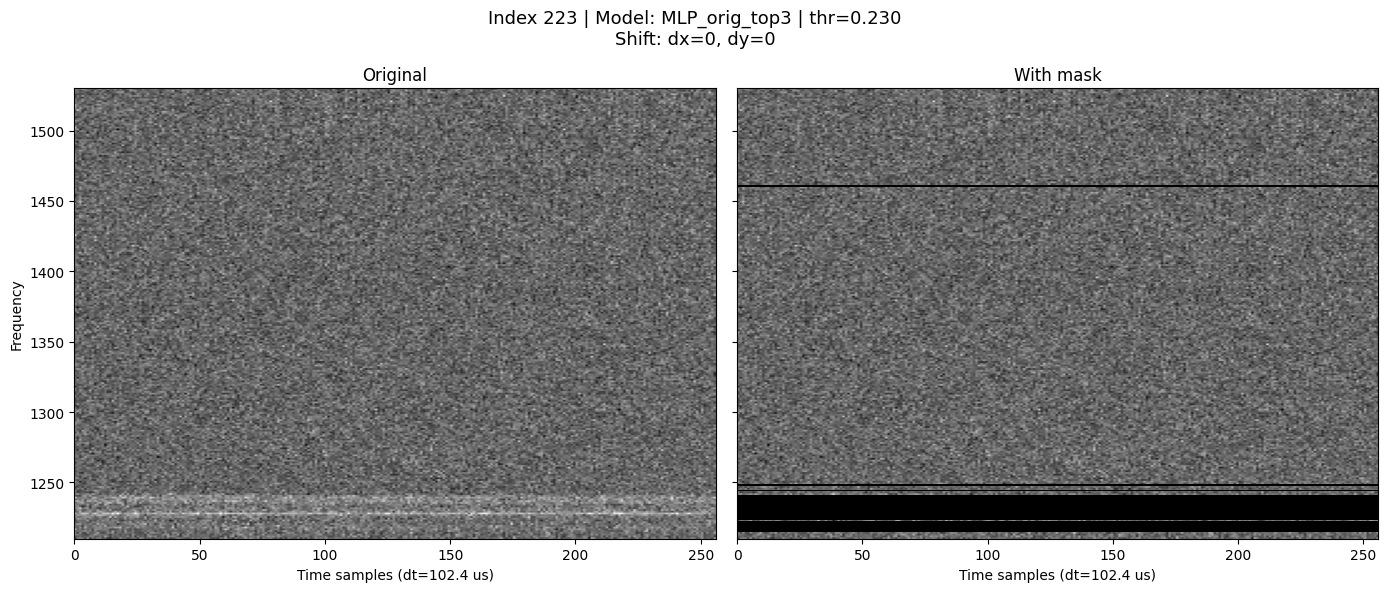

In [198]:
row_mask, probs, feats = plot_spec_with_mask_sklearn(
    filterbank_file,
    index=223,
    pipe=pipe,
    threshold=threshold,     # можно поставить 0.9 как в CNN, но лучше использовать сохранённый
    feature_cols=feature_cols,
    title_name=bundle["model_name"],
    plot=True,
    save=False,
    random_shift=False
)

#print("Predicted RFI channels:", int(row_mask.sum()), "out of", row_mask.size)
#print("probs summary:", np.min(probs), np.mean(probs), np.max(probs))


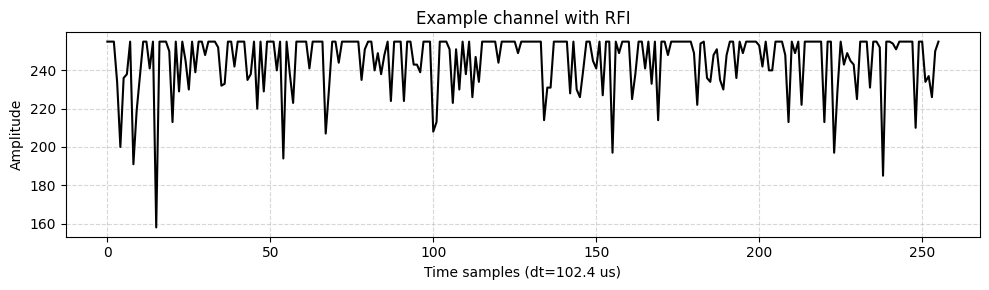

In [57]:
plot_one_channel(filterbank_file, segment_index=46401, channel_index=200, title="Example channel with RFI")

## Global key metrics calculation via average individual segments metrics

### unused indexes for training 

In [95]:
meta_csv_path = 'B0531+21_59000_48386_channels_meta.csv'
meta = pd.read_csv(meta_csv_path)
meta = meta.fillna("None")

/tmp/ipykernel_195289/1557543562.py:2: DtypeWarning: Columns (21,22) have mixed types. Specify dtype option on import or set low_memory=False.
  meta = pd.read_csv(meta_csv_path)


In [96]:
# объединяем все использованные sample_index
used_idx = np.concatenate([train_idx, val_idx, test_idx])

# 2) маска неиспользованных sample_index (сравниваем как строки, чтобы не споткнуться о типы)
unused_mask = ~meta["sample_index"].astype(str).isin(used_idx.astype(str))

# 3) срез неиспользованных
unused = meta.loc[unused_mask, ["segment_index", "label"]].copy()
unused["label"] = unused["label"].astype(str)

unused_segments_by_label = (
    unused.groupby("label")["segment_index"]
          .unique()
          .apply(list)
          .to_dict()
)

unused_segment_nbrfi = unused_segments_by_label.get("NBRFI", [])
unused_segment_none  = unused_segments_by_label.get("None", [])

print(len(unused_segment_none), len(unused_segment_nbrfi))

21095 5483


In [123]:
accuracy_score(y_true, y_pred)
    

0.9140625

In [125]:
precision_recall_fscore_support(y_true, y_pred, average="macro")

(0.7708333333333333, 0.9521739130434783, 0.8262371961002097, None)

In [152]:
individual_key_metrics_segment_none = pd.DataFrame(columns=['segment_index', 'TN', 'FP', 'FN', 'TP', 'accuracy', 'precision', 'recall', 'fscore'])

In [156]:
for idx, segment_index in enumerate(tqdm(unused_segment_none, total=len(unused_segment_none))):
    row_mask, probs, feats = plot_spec_with_mask_sklearn(
        filterbank_file,
        index=segment_index,
        pipe=pipe,
        threshold=threshold,     # можно поставить 0.9 как в CNN, но лучше использовать сохранённый
        feature_cols=feature_cols,
        title_name=bundle["model_name"],
        plot=False,
        save=False,
        random_shift=False
    )
    mask = meta['segment_index'].eq(segment_index)
    y = meta.loc[mask, 'label'].eq('NBRFI').astype(int)
    y_true = np.array(y)
    y_pred = row_mask.astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    accuracy = round(accuracy_score(y_true, y_pred), 4)
    
    precision, recall, fscore, _ = precision_recall_fscore_support(
        y_true, y_pred,
        average="binary",   # метрики только для pos_label
        pos_label=1,
        zero_division=0     # что делать при 0/0
    )
    precision = round(precision, 4)
    recall = round(recall, 4)
    fscore = round(fscore, 4)

    individual_key_metrics_segment_none.loc[idx] = [segment_index, tn, fp, fn, tp, accuracy, precision, recall, fscore]

  0%|          | 0/21095 [00:00<?, ?it/s]

In [157]:
individual_key_metrics_segment_none.head()

,segment_index,TN,FP,FN,TP,accuracy,precision,recall,fscore
0,8776.0,250.0,6.0,0.0,0.0,0.9766,0.0,0.0,0.0
1,8777.0,250.0,6.0,0.0,0.0,0.9766,0.0,0.0,0.0
2,8778.0,254.0,2.0,0.0,0.0,0.9922,0.0,0.0,0.0
3,8779.0,248.0,8.0,0.0,0.0,0.9688,0.0,0.0,0.0
4,8780.0,250.0,6.0,0.0,0.0,0.9766,0.0,0.0,0.0


In [158]:
individual_key_metrics_segment_nbrfi = pd.DataFrame(columns=['segment_index', 'TN', 'FP', 'FN', 'TP', 'accuracy', 'precision', 'recall', 'fscore'])

In [159]:
for idx, segment_index in enumerate(tqdm(unused_segment_nbrfi, total=len(unused_segment_nbrfi))):
    row_mask, probs, feats = plot_spec_with_mask_sklearn(
        filterbank_file,
        index=segment_index,
        pipe=pipe,
        threshold=threshold,     # можно поставить 0.9 как в CNN, но лучше использовать сохранённый
        feature_cols=feature_cols,
        title_name=bundle["model_name"],
        plot=False,
        save=False,
        random_shift=False
    )
    mask = meta['segment_index'].eq(segment_index)
    y = meta.loc[mask, 'label'].eq('NBRFI').astype(int)
    y_true = np.array(y)
    y_pred = row_mask.astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    accuracy = round(accuracy_score(y_true, y_pred), 4)
    
    precision, recall, fscore, _ = precision_recall_fscore_support(
        y_true, y_pred,
        average="binary",   # метрики только для pos_label
        pos_label=1,
        zero_division=0     # что делать при 0/0
    )
    precision = round(precision, 4)
    recall = round(recall, 4)
    fscore = round(fscore, 4)

    individual_key_metrics_segment_nbrfi.loc[idx] = [segment_index, tn, fp, fn, tp, accuracy, precision, recall, fscore]

  0%|          | 0/5483 [00:00<?, ?it/s]

In [160]:
individual_key_metrics_segment_nbrfi.head()

,segment_index,TN,FP,FN,TP,accuracy,precision,recall,fscore
0,223.0,232.0,15.0,1.0,8.0,0.9375,0.3478,0.8889,0.5000
1,224.0,232.0,15.0,1.0,8.0,0.9375,0.3478,0.8889,0.5000
2,225.0,233.0,14.0,1.0,8.0,0.9414,0.3636,0.8889,0.5161
3,226.0,235.0,12.0,1.0,8.0,0.9492,0.4000,0.8889,0.5517
4,227.0,237.0,10.0,0.0,9.0,0.9609,0.4737,1.0000,0.6429


In [178]:
def plot_hists_simple(df: pd.DataFrame, cols=None, bins=30, ncols=3):
    d = df.copy().apply(pd.to_numeric, errors="coerce")

    if cols is None:
        cols = list(d.columns)
    else:
        cols = [c for c in cols if c in d.columns]

    n = len(cols)
    if n == 0:
        print("Нечего рисовать: cols пустой или колонок нет в df.")
        return

    nrows = math.ceil(n / ncols)
    plt.figure(figsize=(4 * ncols, 3 * nrows))

    for i, col in enumerate(cols, start=1):
        plt.subplot(nrows, ncols, i)
        x = d[col].dropna().values

        if x.size == 0:
            plt.title(col)
            plt.text(0.5, 0.5, "empty", ha="center", va="center", transform=plt.gca().transAxes)
            plt.axis("off")
            continue

        plt.hist(x, bins=bins)

        mean_val = float(np.mean(x))
        median_val = float(np.median(x))

        # обе линии чёрные
        plt.axvline(mean_val, color="black", linestyle="-", linewidth=2, label=f"mean={mean_val:.4g}")
        plt.axvline(median_val, color="black", linestyle="--", linewidth=2, label=f"median={median_val:.4g}")

        plt.title(col)
        plt.xlabel(col)
        plt.ylabel("count")
        plt.grid(True, ls="--")
        plt.legend()

    plt.tight_layout()
    plt.show()

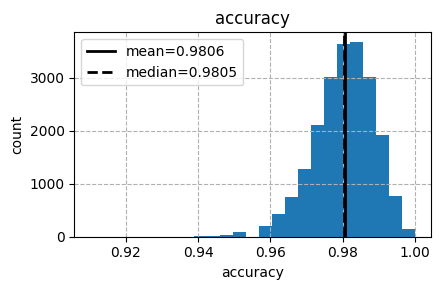

In [179]:
plot_hists_simple(individual_key_metrics_segment_none, cols=['accuracy'], bins=25)

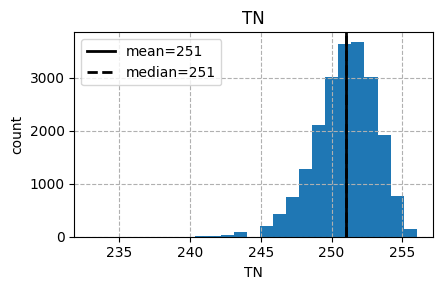

In [180]:
plot_hists_simple(individual_key_metrics_segment_none, cols=['TN'], bins=25)

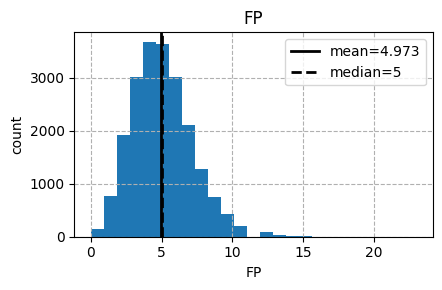

In [181]:
plot_hists_simple(individual_key_metrics_segment_none, cols=['FP'], bins=25)

In [182]:
----

SyntaxError: invalid syntax (2133496677.py, line 1)

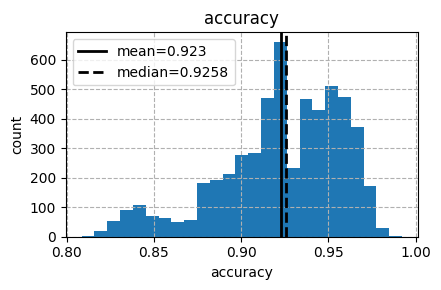

In [183]:
plot_hists_simple(individual_key_metrics_segment_nbrfi, cols=['accuracy'], bins=25)

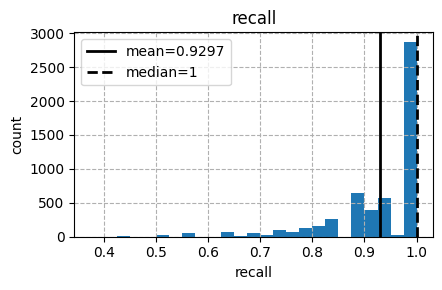

In [184]:
plot_hists_simple(individual_key_metrics_segment_nbrfi, cols=['recall'], bins=25)

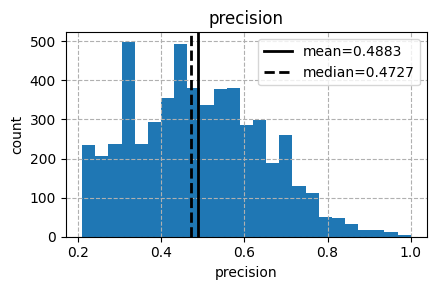

In [185]:
plot_hists_simple(individual_key_metrics_segment_nbrfi, cols=['precision'], bins=25)

In [ ]:
metric = 'precision'
upper_limit = 0.5

table = individual_key_metrics_segment_nbrfi[individual_key_metrics_segment_nbrfi[metric] <= upper_limit]

out_dir = f"individual_key_metrics_segment_nbrf_{metric}_leq_{upper_limit}"

for row in tqdm(table.itertuples(index=True), total=len(table), desc="Processing"):
    # idx = row.Index  # если нужен индекс датафрейма

    segment_index = int(row.segment_index)

    row_mask, probs, feats = plot_spec_with_mask_sklearn(
        filterbank_file,
        index=segment_index,
        pipe=pipe,
        threshold=threshold,
        feature_cols=feature_cols,
        title_name=bundle["model_name"],
        addition_to_title=(
            f"\nAcc: {row.accuracy}, P: {row.precision}, R: {row.recall}, F1: {row.fscore}"
        ),
        plot=True,
        save=True,
        out_dir=out_dir,
        random_shift=False
    )

In [223]:
len(list(map(lambda x: os.path.basename(x),  glob.glob('individual_key_metrics_segment_nbrf_*/*'))))

5892

## Metrics Measurment 

## мы переопределеям функию для определения фичей

In [245]:
extract_features_from_segment_full = extract_features_from_segment

In [246]:
def _mean_std(x, axis):
    mean = x.mean(axis=axis)
    std  = x.std(axis=axis)
    return mean, std

def _skew_kurt_from_centered(centered, std, axis):
    # centered = x - mean
    m3 = (centered**3).mean(axis=axis)
    m4 = (centered**4).mean(axis=axis)
    std_safe = np.where(std == 0, 1.0, std)
    skew = m3 / (std_safe**3)
    kurt = m4 / (std_safe**4) - 3.0
    return skew, kurt

def _normalize_per_channel(seg):
    # (H,W) -> (H,W)
    seg = np.asarray(seg)
    mn = seg.min(axis=1, keepdims=True)
    mx = seg.max(axis=1, keepdims=True)
    denom = mx - mn
    denom = np.where(denom == 0, 1.0, denom)
    return (seg - mn) / denom * 256.0

def make_fast_extractor(feature_cols):
    needed = set(feature_cols)

    allowed = {
        "mean_o","std_o","skew_o","kurt_o",
        "mean_n","std_n","skew_n","kurt_n",
        "mean_o_ratio","std_o_ratio","skew_o_ratio","kurt_o_ratio",
        "mean_n_ratio","std_n_ratio","skew_n_ratio","kurt_n_ratio",
    }
    unknown = needed - allowed
    if unknown:
        raise ValueError(f"Unknown feature names: {sorted(unknown)}")

    # что вообще нужно
    need_o = any(c.endswith("_o") or c.endswith("_o_ratio") for c in needed)
    need_n = any(c.endswith("_n") or c.endswith("_n_ratio") for c in needed)
    need_ratio_o = any(c.endswith("_o_ratio") for c in needed)
    need_ratio_n = any(c.endswith("_n_ratio") for c in needed)

    need_skew_o = ("skew_o" in needed) or ("skew_o_ratio" in needed)
    need_kurt_o = ("kurt_o" in needed) or ("kurt_o_ratio" in needed)
    need_skew_n = ("skew_n" in needed) or ("skew_n_ratio" in needed)
    need_kurt_n = ("kurt_n" in needed) or ("kurt_n_ratio" in needed)

    need_mean_o = ("mean_o" in needed) or ("mean_o_ratio" in needed)
    need_std_o  = ("std_o"  in needed) or ("std_o_ratio"  in needed)
    need_mean_n = ("mean_n" in needed) or ("mean_n_ratio" in needed)
    need_std_n  = ("std_n"  in needed) or ("std_n_ratio"  in needed)

    def extractor(seg: np.ndarray) -> pd.DataFrame:
        seg = np.asarray(seg)
        if seg.ndim != 2:
            raise ValueError(f"Expected seg (H,W), got {seg.shape}")
        H, W = seg.shape

        out = {}

        # --- ORIGINAL per-channel stats ---
        if need_o:
            if need_mean_o or need_std_o or need_skew_o or need_kurt_o:
                mean_o, std_o = _mean_std(seg, axis=1)
                if need_mean_o: out["mean_o"] = mean_o
                if need_std_o:  out["std_o"]  = std_o

                if need_skew_o or need_kurt_o:
                    centered = seg - mean_o[:, None]
                    skew_o, kurt_o = _skew_kurt_from_centered(centered, std_o, axis=1)
                    if ("skew_o" in needed) or ("skew_o_ratio" in needed):
                        out["skew_o"] = skew_o
                    if ("kurt_o" in needed) or ("kurt_o_ratio" in needed):
                        out["kurt_o"] = kurt_o

            # --- ORIGINAL segment-level stats for ratios ---
            if need_ratio_o:
                flat = seg.reshape(-1)
                seg_mean_o, seg_std_o = _mean_std(flat, axis=0)

                seg_skew_o = seg_kurt_o = None
                if ("skew_o_ratio" in needed) or ("kurt_o_ratio" in needed):
                    centered = flat - seg_mean_o
                    seg_skew_o, seg_kurt_o = _skew_kurt_from_centered(centered, np.array(seg_std_o), axis=0)

                def ratio(arr, denom):
                    denom = float(denom)
                    if denom == 0:
                        return np.full(H, np.nan, dtype=float)
                    return np.asarray(arr, dtype=float) / denom

                if "mean_o_ratio" in needed:
                    out["mean_o_ratio"] = ratio(out.get("mean_o", mean_o), seg_mean_o)
                if "std_o_ratio" in needed:
                    out["std_o_ratio"]  = ratio(out.get("std_o", std_o), seg_std_o)
                if "skew_o_ratio" in needed:
                    out["skew_o_ratio"] = ratio(out.get("skew_o", skew_o), seg_skew_o)
                if "kurt_o_ratio" in needed:
                    out["kurt_o_ratio"] = ratio(out.get("kurt_o", kurt_o), seg_kurt_o)

        # --- NORMALIZED seg_n and stats ---
        if need_n:
            seg_n = _normalize_per_channel(seg)

            mean_n, std_n = _mean_std(seg_n, axis=1)
            if need_mean_n: out["mean_n"] = mean_n
            if need_std_n:  out["std_n"]  = std_n

            if need_skew_n or need_kurt_n:
                centered = seg_n - mean_n[:, None]
                skew_n, kurt_n = _skew_kurt_from_centered(centered, std_n, axis=1)
                if ("skew_n" in needed) or ("skew_n_ratio" in needed):
                    out["skew_n"] = skew_n
                if ("kurt_n" in needed) or ("kurt_n_ratio" in needed):
                    out["kurt_n"] = kurt_n

            if need_ratio_n:
                flat = seg_n.reshape(-1)
                seg_mean_n, seg_std_n = _mean_std(flat, axis=0)

                seg_skew_n = seg_kurt_n = None
                if ("skew_n_ratio" in needed) or ("kurt_n_ratio" in needed):
                    centered = flat - seg_mean_n
                    seg_skew_n, seg_kurt_n = _skew_kurt_from_centered(centered, np.array(seg_std_n), axis=0)

                def ratio(arr, denom):
                    denom = float(denom)
                    if denom == 0:
                        return np.full(H, np.nan, dtype=float)
                    return np.asarray(arr, dtype=float) / denom

                if "mean_n_ratio" in needed:
                    out["mean_n_ratio"] = ratio(out.get("mean_n", mean_n), seg_mean_n)
                if "std_n_ratio" in needed:
                    out["std_n_ratio"]  = ratio(out.get("std_n", std_n), seg_std_n)
                if "skew_n_ratio" in needed:
                    out["skew_n_ratio"] = ratio(out.get("skew_n", skew_n), seg_skew_n)
                if "kurt_n_ratio" in needed:
                    out["kurt_n_ratio"] = ratio(out.get("kurt_n", kurt_n), seg_kurt_n)

        # Собираем DataFrame ТОЛЬКО с нужными колонками и в нужном порядке
        df = pd.DataFrame({c: out[c] for c in feature_cols})
        return df

    return extractor


In [247]:
# feature_cols — это те самые 3 (или сколько) фич, которые реально использует модель
extract_features_from_segment = make_fast_extractor(feature_cols)

print("Now extract_features_from_segment computes only:", feature_cols)


Now extract_features_from_segment computes only: ['mean_o', 'std_o', 'skew_o']


### параметры, бюджет, число сегментов

In [248]:
nsamp = 256

def tsamp_to_seconds(tsamp):
    if hasattr(tsamp, "to_value"):
        return float(tsamp.to_value("s"))
    return float(tsamp)

tsamp_sec = tsamp_to_seconds(filterbank_file.your_header.tsamp)
budget_ms = 1e3 * nsamp * tsamp_sec

n_total_segments = filterbank_file.your_header.nspectra // nsamp

print(f"tsamp = {tsamp_sec*1e6:.3f} µs")
print(f"Budget per segment = {budget_ms:.3f} ms  ({nsamp} samples)")
print(f"Total segments available = {n_total_segments}")

tsamp = 102.400 µs
Budget per segment = 26.214 ms  (256 samples)
Total segments available = 50071


### функции: загрузка + один инференс + бенч по списку сегментов

In [249]:
def load_segment(filterbank_file, segment_index: int, nsamp: int = 256):
    steps = segment_index * nsamp
    data = filterbank_file.get_data(nstart=steps, nsamp=nsamp).T  # (n_chan, 256)
    return np.asarray(data)

def infer_on_data(data, pipe, threshold, feature_cols):
    # важно: без plot/save
    return predict_mask_for_segment(data, pipe, threshold, feature_cols)

def bench_segment_indices(
    filterbank_file,
    segment_indices,
    pipe,
    threshold,
    feature_cols,
    nsamp: int = 256,
    warmup: int = 10,
    mode: str = "e2e",          # "e2e" или "infer_only"
    repeats_per_segment: int = 1,
):
    """
    mode="e2e": меряем load+infer для каждого сегмента
    mode="infer_only": меряем только infer на уже загруженном data (CPU/модель без IO)
    repeats_per_segment: сколько раз повторять инференс на одном и том же сегменте
    """
    segment_indices = list(map(int, segment_indices))
    assert len(segment_indices) > 0

    # warmup на первом сегменте (прогрев аллокаций/кэшей/первого вызова)
    d0 = load_segment(filterbank_file, segment_indices[0], nsamp=nsamp)
    for _ in range(warmup):
        _ = infer_on_data(d0, pipe, threshold, feature_cols)

    times = []

    if mode == "infer_only":
        # загружаем один раз каждый сегмент, потом меряем только инференс
        for idx in segment_indices:
            data = load_segment(filterbank_file, idx, nsamp=nsamp)
            for _ in range(repeats_per_segment):
                t0 = time.perf_counter()
                _ = infer_on_data(data, pipe, threshold, feature_cols)
                times.append(time.perf_counter() - t0)

    elif mode == "e2e":
        for idx in segment_indices:
            for _ in range(repeats_per_segment):
                t0 = time.perf_counter()
                data = load_segment(filterbank_file, idx, nsamp=nsamp)
                _ = infer_on_data(data, pipe, threshold, feature_cols)
                times.append(time.perf_counter() - t0)
    else:
        raise ValueError("mode must be 'e2e' or 'infer_only'")

    return np.asarray(times, dtype=float)

def summarize_ms(t_sec: np.ndarray):
    x = np.asarray(t_sec, dtype=float) * 1e3
    return {
        "count": int(x.size),
        "mean_ms": float(x.mean()),
        "median_ms": float(np.median(x)),
        "p95_ms": float(np.percentile(x, 95)),
        "min_ms": float(x.min()),
        "max_ms": float(x.max()),
    }


### Ячейка 3 — прогон N=1,10,100,1000 (и адаптивные повторы)

Тут мы делаем два режима:

e2e_random: случайные сегменты (реалистично по данным, но IO кэш может прыгать)

e2e_sequential: последовательные сегменты (похоже на стриминг)

In [250]:
rng = np.random.default_rng(42)

N_list = [1, 10, 100, 1000]
N_list = [N for N in N_list if N <= n_total_segments]

def repeats_for_N(N):
    # чтобы не взорваться по времени:
    # на маленьких N делаем больше повторов, на больших — меньше
    if N <= 1:   return 200
    if N <= 10:  return 50
    if N <= 100: return 10
    return 1

rows = []

for N in tqdm(N_list, total=len(N_list)):
    reps = repeats_for_N(N)

    # random indices
    idx_rand = rng.choice(n_total_segments, size=N, replace=False)

    # sequential indices (берём первые N)
    idx_seq = np.arange(N, dtype=int)

    # меряем
    t_rand = bench_segment_indices(
        filterbank_file, idx_rand, pipe, threshold, feature_cols,
        nsamp=nsamp, warmup=10, mode="e2e", repeats_per_segment=reps
    )
    t_seq = bench_segment_indices(
        filterbank_file, idx_seq, pipe, threshold, feature_cols,
        nsamp=nsamp, warmup=10, mode="e2e", repeats_per_segment=reps
    )

    s_rand = summarize_ms(t_rand)
    s_seq  = summarize_ms(t_seq)

    # добавим сравнение с budget
    for tag, s in [("random", s_rand), ("sequential", s_seq)]:
        rt_factor_p95 = budget_ms / s["p95_ms"]
        rows.append({
            "N_segments": N,
            "pattern": tag,
            "repeats_per_segment": reps,
            **s,
            "budget_ms": float(budget_ms),
            "rt_factor_p95": float(rt_factor_p95),
            "rt_ok_p95": bool(s["p95_ms"] < budget_ms),
        })

df = pd.DataFrame(rows).sort_values(["pattern", "N_segments"])
df


  0%|          | 0/4 [00:00<?, ?it/s]

,N_segments,pattern,repeats_per_segment,count,mean_ms,median_ms,p95_ms,min_ms,max_ms,budget_ms,rt_factor_p95,rt_ok_p95
0,1,random,200,200,13.377591,13.402522,13.470041,13.262272,14.332131,26.2144,1.946126,True
2,10,random,50,500,13.769338,13.654016,15.032077,13.486207,16.104624,26.2144,1.743897,True
4,100,random,10,1000,13.635763,13.644241,13.722752,13.368234,16.630925,26.2144,1.910287,True
6,1000,random,1,1000,13.685124,13.666503,13.751126,13.211511,16.621836,26.2144,1.906346,True
1,1,sequential,200,200,13.691278,13.721053,13.759845,13.581462,14.262967,26.2144,1.905138,True
3,10,sequential,50,500,13.644910,13.654519,13.733126,13.488494,15.304275,26.2144,1.908844,True
5,100,sequential,10,1000,13.647567,13.657589,13.723422,13.486125,16.974114,26.2144,1.910194,True
7,1000,sequential,1,1000,13.651414,13.662595,13.727461,13.472110,15.086569,26.2144,1.909632,True


## красивый график: mean/p95 vs N + линия бюджета

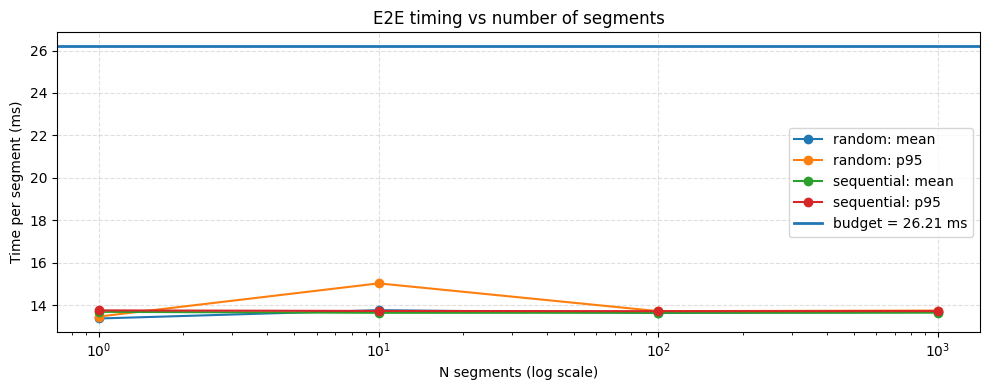

In [251]:
plt.figure(figsize=(10, 4))

for pattern in ["random", "sequential"]:
    d = df[df["pattern"] == pattern].sort_values("N_segments")
    plt.plot(d["N_segments"], d["mean_ms"], marker="o", label=f"{pattern}: mean")
    plt.plot(d["N_segments"], d["p95_ms"], marker="o", label=f"{pattern}: p95")

plt.axhline(budget_ms, linewidth=2, label=f"budget = {budget_ms:.2f} ms")
plt.xscale("log")
plt.xlabel("N segments (log scale)")
plt.ylabel("Time per segment (ms)")
plt.title("E2E timing vs number of segments")
plt.grid(True, ls="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

## график “во сколько раз быстрее real-time” (по p95)

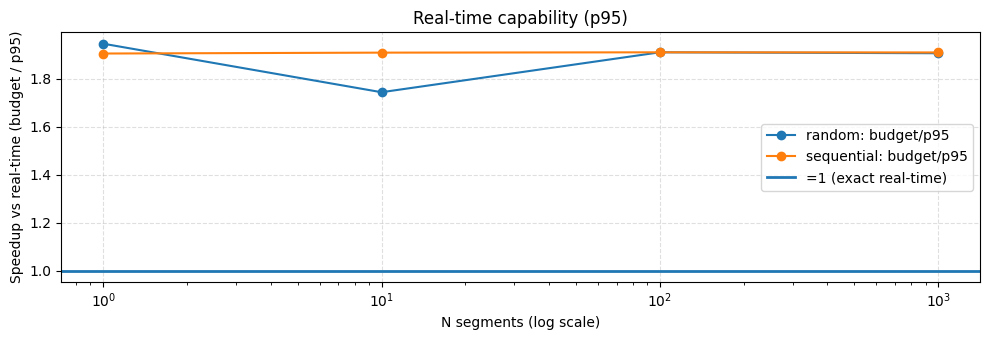

In [252]:
plt.figure(figsize=(10, 3.5))
for pattern in ["random", "sequential"]:
    d = df[df["pattern"] == pattern].sort_values("N_segments")
    plt.plot(d["N_segments"], d["rt_factor_p95"], marker="o", label=f"{pattern}: budget/p95")

plt.axhline(1.0, linewidth=2, label="=1 (exact real-time)")
plt.xscale("log")
plt.xlabel("N segments (log scale)")
plt.ylabel("Speedup vs real-time (budget / p95)")
plt.title("Real-time capability (p95)")
plt.grid(True, ls="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

In [253]:
## “стабилизируется ли среднее”: rolling mean на длинном прогоне

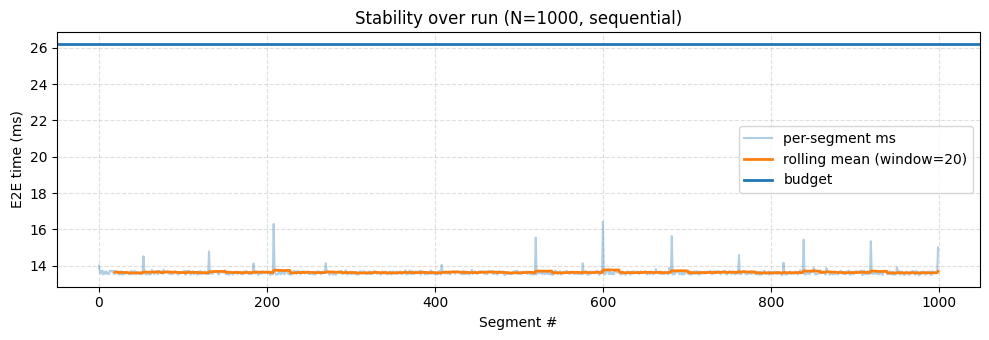

In [254]:
# возьмём самый большой N из списка (например 1000) и сделаем один прогон без повторов
N_big = max(N_list)
idx_big = np.arange(N_big, dtype=int)  # sequential
t_big = bench_segment_indices(
    filterbank_file, idx_big, pipe, threshold, feature_cols,
    nsamp=nsamp, warmup=10, mode="e2e", repeats_per_segment=1
)
x = (t_big * 1e3)

window = max(5, N_big // 50)  # ~2% окна
rolling = pd.Series(x).rolling(window=window).mean()

plt.figure(figsize=(10, 3.5))
plt.plot(x, alpha=0.35, label="per-segment ms")
plt.plot(rolling, linewidth=2, label=f"rolling mean (window={window})")
plt.axhline(budget_ms, linewidth=2, label="budget")
plt.xlabel("Segment #")
plt.ylabel("E2E time (ms)")
plt.title(f"Stability over run (N={N_big}, sequential)")
plt.grid(True, ls="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

## Разделение еще и на отдельно по элементам

In [255]:
def predict_mask_for_segment_timed(seg: np.ndarray, pipe, threshold: float, feature_cols: list):
    """
    Возвращает:
      mask: (n_channels,) bool
      probs: (n_channels,) float
      feats: DataFrame
      t: dict с временами (сек)
    """
    t = {}
    t0 = time.perf_counter()

    # 1) feature extraction
    a0 = time.perf_counter()
    feats = extract_features_from_segment(seg)
    a1 = time.perf_counter()
    t["features"] = a1 - a0

    # 2) reorder columns
    b0 = time.perf_counter()
    feats = feats[feature_cols]
    b1 = time.perf_counter()
    t["reorder"] = b1 - b0

    # 3) prediction (включая трансформы внутри pipe)
    c0 = time.perf_counter()
    if hasattr(pipe, "predict_proba"):
        probs = pipe.predict_proba(feats)[:, 1]
    else:
        scores = pipe.decision_function(feats)
        probs = expit(scores)
    c1 = time.perf_counter()
    t["pipe_predict"] = c1 - c0

    # 4) thresholding
    d0 = time.perf_counter()
    mask = probs >= threshold
    d1 = time.perf_counter()
    t["threshold"] = d1 - d0

    t["infer_total"] = time.perf_counter() - t0
    return mask, probs, feats, t


## бенч по многим сегментам с разбиением LOAD vs INFER(внутри)

Эта ячейка даст массивы времен:

t_load: только чтение сегмента

t_features, t_reorder, t_pipe, t_threshold

t_infer_total (сумма шагов инференса)

t_e2e (load + infer)

In [256]:
nsamp = 256

def tsamp_to_seconds(tsamp):
    if hasattr(tsamp, "to_value"):
        return float(tsamp.to_value("s"))
    return float(tsamp)

def load_segment(filterbank_file, segment_index: int, nsamp: int = 256):
    nstart = segment_index * nsamp
    data = filterbank_file.get_data(nstart=nstart, nsamp=nsamp).T  # (n_chan, 256)
    return np.asarray(data)

def bench_breakdown_segments(
    filterbank_file,
    segment_indices,
    pipe,
    threshold,
    feature_cols,
    nsamp: int = 256,
    warmup: int = 10,
):
    segment_indices = list(map(int, segment_indices))
    assert segment_indices, "segment_indices пуст"

    # warmup
    d0 = load_segment(filterbank_file, segment_indices[0], nsamp=nsamp)
    for _ in range(warmup):
        _ = predict_mask_for_segment_timed(d0, pipe, threshold, feature_cols)

    # arrays
    n = len(segment_indices)
    t_load = np.empty(n, dtype=float)
    t_features = np.empty(n, dtype=float)
    t_reorder = np.empty(n, dtype=float)
    t_pipe = np.empty(n, dtype=float)
    t_thr = np.empty(n, dtype=float)
    t_infer_total = np.empty(n, dtype=float)
    t_e2e = np.empty(n, dtype=float)

    for i, idx in enumerate(segment_indices):
        e0 = time.perf_counter()

        # LOAD
        a0 = time.perf_counter()
        data = load_segment(filterbank_file, idx, nsamp=nsamp)
        a1 = time.perf_counter()
        t_load[i] = a1 - a0

        # INFER breakdown
        _, _, _, tt = predict_mask_for_segment_timed(data, pipe, threshold, feature_cols)
        t_features[i] = tt["features"]
        t_reorder[i] = tt["reorder"]
        t_pipe[i] = tt["pipe_predict"]
        t_thr[i] = tt["threshold"]
        t_infer_total[i] = tt["infer_total"]

        t_e2e[i] = time.perf_counter() - e0

    return {
        "load": t_load,
        "features": t_features,
        "reorder": t_reorder,
        "pipe_predict": t_pipe,
        "threshold": t_thr,
        "infer_total": t_infer_total,
        "e2e": t_e2e,
    }


прогон на N сегментах (1/10/100/1000) и сводная таблица

In [257]:
tsamp_sec = tsamp_to_seconds(filterbank_file.your_header.tsamp)
budget_ms = 1e3 * nsamp * tsamp_sec
n_total_segments = filterbank_file.your_header.nspectra // nsamp

print(f"Budget per segment = {budget_ms:.3f} ms")
print(f"Total segments = {n_total_segments}")

rng = np.random.default_rng(42)

N_list = [1, 10, 100, 1000]
N_list = [N for N in N_list if N <= n_total_segments]

def summarize_ms(x):
    x = np.asarray(x) * 1e3
    return {
        "mean_ms": float(x.mean()),
        "median_ms": float(np.median(x)),
        "p95_ms": float(np.percentile(x, 95)),
    }

rows = []

for N in N_list:
    # random segments (более честно к разным данным)
    seg_idx = rng.choice(n_total_segments, size=N, replace=False)

    times = bench_breakdown_segments(
        filterbank_file, seg_idx, pipe, threshold, feature_cols,
        nsamp=nsamp, warmup=10
    )

    # summary по компонентам
    parts = ["load", "features", "reorder", "pipe_predict", "threshold", "infer_total", "e2e"]
    summ = {p: summarize_ms(times[p]) for p in parts}

    # доля времени "модель считает" = infer_total / e2e
    share_median = summ["infer_total"]["median_ms"] / summ["e2e"]["median_ms"]
    share_p95    = summ["infer_total"]["p95_ms"]    / summ["e2e"]["p95_ms"]

    rows.append({
        "N": N,
        "budget_ms": budget_ms,
        "e2e_median_ms": summ["e2e"]["median_ms"],
        "e2e_p95_ms": summ["e2e"]["p95_ms"],
        "infer_median_ms": summ["infer_total"]["median_ms"],
        "infer_p95_ms": summ["infer_total"]["p95_ms"],
        "load_median_ms": summ["load"]["median_ms"],
        "load_p95_ms": summ["load"]["p95_ms"],
        "share_model_median": share_median,
        "share_model_p95": share_p95,
        "rt_ok_p95": summ["e2e"]["p95_ms"] < budget_ms,
        # доп: внутри инференса
        "features_median_ms": summ["features"]["median_ms"],
        "pipe_predict_median_ms": summ["pipe_predict"]["median_ms"],
    })

df = pd.DataFrame(rows)
df


Budget per segment = 26.214 ms
Total segments = 50071


,N,budget_ms,e2e_median_ms,e2e_p95_ms,infer_median_ms,infer_p95_ms,load_median_ms,load_p95_ms,share_model_median,share_model_p95,rt_ok_p95,features_median_ms,pipe_predict_median_ms
0,1,26.2144,13.342254,13.342254,13.281725,13.281725,0.044331,0.044331,0.995463,0.995463,True,10.576814,2.233282
1,10,26.2144,13.491392,14.725722,13.428442,14.667103,0.045341,0.047592,0.995334,0.996019,True,10.763820,2.264913
2,100,26.2144,13.557300,13.603979,13.498899,13.546178,0.044242,0.045347,0.995692,0.995751,True,10.803528,2.236675
3,1000,26.2144,13.556615,13.624028,13.498947,13.565840,0.044368,0.047283,0.995746,0.995729,True,10.796472,2.245642


красивый график: вклад LOAD vs INFER (median и p95) + линия бюджета

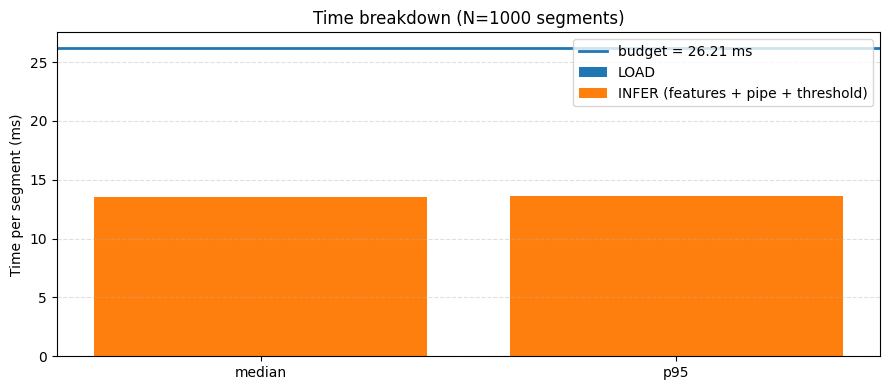

In [258]:
# возьмём самый большой N (самая стабильная оценка)
N_best = df["N"].max()
# чтобы использовать те же сегменты, проще сделать отдельный прогон на N_best:
seg_idx = rng.choice(n_total_segments, size=int(N_best), replace=False)
times = bench_breakdown_segments(filterbank_file, seg_idx, pipe, threshold, feature_cols, nsamp=nsamp, warmup=10)

def p(x, q): 
    return float(np.percentile(np.asarray(x)*1e3, q))

load_med, load_p95 = p(times["load"], 50), p(times["load"], 95)
inf_med,  inf_p95  = p(times["infer_total"], 50), p(times["infer_total"], 95)

labels = ["median", "p95"]
load_vals = [load_med, load_p95]
inf_vals  = [inf_med,  inf_p95]

x = np.arange(2)
plt.figure(figsize=(9, 4))
plt.bar(x, load_vals, label="LOAD")
plt.bar(x, inf_vals, bottom=load_vals, label="INFER (features + pipe + threshold)")
plt.axhline(budget_ms, linewidth=2, label=f"budget = {budget_ms:.2f} ms")
plt.xticks(x, labels)
plt.ylabel("Time per segment (ms)")
plt.title(f"Time breakdown (N={int(N_best)} segments)")
plt.grid(True, axis="y", ls="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


In [259]:
print(f"Доля вычислений (median): {inf_med/(load_med+inf_med):.2%}")
print(f"Доля вычислений (p95):    {inf_p95/(load_p95+inf_p95):.2%}")

Доля вычислений (median): 99.67%
Доля вычислений (p95):    99.64%


ещё полезнее: внутри INFER (features vs pipe)

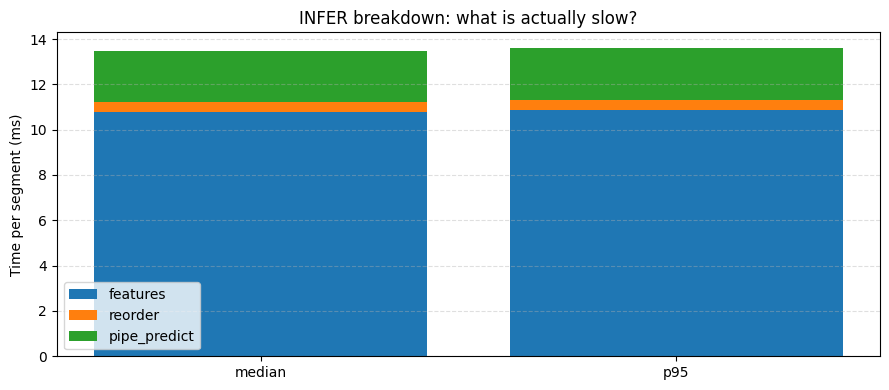

In [260]:
feat_med, feat_p95 = p(times["features"], 50), p(times["features"], 95)
pipe_med, pipe_p95 = p(times["pipe_predict"], 50), p(times["pipe_predict"], 95)
reor_med, reor_p95 = p(times["reorder"], 50), p(times["reorder"], 95)

labels = ["median", "p95"]
x = np.arange(2)

bottom1 = [0, 0]
plt.figure(figsize=(9, 4))
plt.bar(x, [feat_med, feat_p95], label="features")
plt.bar(x, [reor_med, reor_p95], bottom=[feat_med, feat_p95], label="reorder")
plt.bar(x, [pipe_med, pipe_p95], bottom=[feat_med+reor_med, feat_p95+reor_p95], label="pipe_predict")
plt.xticks(x, labels)
plt.ylabel("Time per segment (ms)")
plt.title("INFER breakdown: what is actually slow?")
plt.grid(True, axis="y", ls="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()
